<a href="https://colab.research.google.com/github/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/collections_demos/bonemarrowwsi_pediatricleukemia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Where cells come from: exploring bone marrow with the `BoneMarrowWSI-PediatricLeukemia` collection

This tutorial is shared as part of the tutorials prepared by the Imaging Data Commons (IDC) team and available at https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks.

If you are new to IDC and DICOM for digital pathology applications, you may want to check out other introductory tutorials on this topic available here: https://github.com/ImagingDataCommons/IDC-Tutorials/tree/master/notebooks/pathomics.

This tutorial is aimed at users of the IDC that are interested in **bone marrow smear analysis**. You will learn how to:
* select and access images and image-derived data (in this case, manual expert annotations) of the comprehensive bone marrow collection `BoneMarrowWSI-PediatricLeukemia`
* parse and understand the available content stored in DICOM Bulk Simple Annotations (MBSA/ANN) files

To learn more about the IDC, please visit the [IDC user guide](https://learn.canceridc.dev).

If you have any questions, bug reports, or feature requests, please feel free to contact us at the [IDC discussion forum](https://discourse.canceridc.dev)!

----------------------

Initial version: Feb 2026  
Updated: Aug 2026

## Background

The analysis of bone marrow aspirate smears serves as the foundation for assessing haematopoiesis (the process of blood cell formation in the bone marrow) and amongst other systemic diseases, the diagnosis of leukemia. This notebook introduces the `BoneMarrowWSI-PediatricLeukemia` collection, a comprehensive dataset of bone marrow smears and cell annotations. The dataset is presented in detail in [this preprint](https://www.arxiv.org/pdf/2509.15895) and is publicly available via the [Imaging Data Commons](https://portal.imaging.datacommons.cancer.gov/).

- **Images**: The `BoneMarrowWSI-PediatricLeukemia` dataset comprises bone marrow aspirate smear whole slide images (WSIs) for almost 250 pediatric cases of leukemia, including acute lymphoid leukemia (ALL), acute myeloid leukemia (AML), and chronic myeloid leukemia (CML). The smears were prepared for the initial diagnosis (i.e., without prior treatment), stained in accordance with the Pappenheim method, and scanned at 40x magnification.
- **Annotations**: The images have been annotated with rectangular regions of interest (ROIs) of the evaluable monolayer area and more than 40,000 cell bounding box annotations have been placed (with few exceptions) within the ROIs. For a subset of them all cells and other haematological structures have additionally been labeled by multiple experts in a consensus labeling approach with 49 distinct (cell type) labels. This approach had worked as follows: each bounding box had been successively labeled by different experts in so-called "annotation sessions" until (a) the bounding box had been labeled by at least two experts, and (b) the most frequent label had constituted at least half of all labels given to that bounding box (and had then been termed "consensus"). In summary, the following annotations are available:  

    - For each slide: ROIs of the monolayer area for each slide
    - For some slides: Unlabeled cell bounding boxes
    - For some slides: Cell bounding boxes with cell type labels for each annotation session plus the finally obtained consensus.

Both images and annotations are made available in the DICOM format. For the annotations, more specifically, the **DICOM Microscopy Bulk Simple Annotation format** (**MBSA**, often also abbreviated ANN after the corresponding DICOM `Modality` value) was used, which is one of multiple options to store pathology image-derived data in DICOM. As a general introduction to this format, we recommend having a look at [this tutorial notebook](https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/pathomics/microscopy_dicom_ann_intro.ipynb).

In the following, we demonstrate **how to access and explore** the `BoneMarrowWSI-PediatricLeukemia` collection with a focus on its extensive annotation data.


<img src="https://raw.githubusercontent.com/ImagingDataCommons/IDC-Tutorials/master/notebooks/collection_demos/bmdeep_annotations_example.png" alt="Example visualization of BoneMarrowWSI-PediatricLeukemia annotations" width="1000"/>



## Prerequisites
**Installations**
* **Install highdicom:** [highdicom](https://highdicom.readthedocs.io/en/latest/introduction.html) was specifically designed to work with DICOM objects holding image-derived information, e.g. annotations and segmentations. Detailed information on `highdicom`'s functionality can be found in its [user guide](https://highdicom.readthedocs.io/en/latest/usage.html).
* **Install wsidicom:** The [wsidicom](https://pypi.org/project/wsidicom/) Python package provides functionality to open and extract image or metadata from WSIs.
* **Install idc-index:** The Python package [idc-index](https://pypi.org/project/idc-index/) facilitates queries of the basic metadata and download of DICOM files hosted by the IDC.

In [1]:
%%capture
!pip install highdicom
!pip install wsidicom
!pip install idc-index --upgrade

## Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import highdicom as hd
from idc_index import IDCClient
from google.cloud import storage
from pathlib import Path
from typing import List, Union

## Finding the `BoneMarrowWSI-PediatricLeukemia` dataset on IDC
To locate and download slides and available annotations, we use the Python package [idc-index](https://github.com/ImagingDataCommons/idc-index) and fetch `ann_index` and `ann_group_index`, specific to DICOM MBSA/ANN objects. Have a look [here](https://idc-index.readthedocs.io/en/latest/indices_reference.html) for details on all available indices in idc-index and what information you can query from them.

In [3]:
idc_client = IDCClient() # set-up idc_client
idc_client.fetch_index('ann_index') # fetch index for MBSA objects
idc_client.fetch_index('ann_group_index') # fetch index for the AnnotationGroups within MBSA objects

First, we count the number of slides (=distinct `SeriesInstanceUIDs` of SM modality) available in the `BoneMarrowWSI-PediatricLeukemia` collection.

In [4]:
query_slide_count = '''
SELECT COUNT(DISTINCT SeriesInstanceUID)
FROM
    index
WHERE
    collection_id = 'bonemarrowwsi_pediatricleukemia' AND Modality='SM'
'''
print(idc_client.sql_query(query_slide_count))

   count(DISTINCT SeriesInstanceUID)
0                                245


Let's have a look at the available MBSA files. The following query collects series-level information from the `ann_index` of idc-index, joined with the common index table on `SeriesInstanceUID`.

In [5]:
query_anns = '''
SELECT
    ann_index.SeriesInstanceUID, -- SeriesInstanceUID of the annotation object
    ann_index.referenced_SeriesInstanceUID, -- SeriesInstanceUID of the slide that the annotation is associated with
    ann_index.AnnotationCoordinateType, -- whether coordinates are 2D (image coordinate system) or 3D (frame-of-reference coordinate system)
    index.SeriesDescription,
    index.StudyInstanceUID,
FROM
    ann_index
JOIN index
  ON index.SeriesInstanceUID = ann_index.SeriesInstanceUID
WHERE
    index.collection_id = 'bonemarrowwsi_pediatricleukemia'
ORDER BY
    ann_index.referenced_SeriesInstanceUID
'''
annotations = idc_client.sql_query(query_anns)
display(annotations)

,SeriesInstanceUID,referenced_SeriesInstanceUID,AnnotationCoordinateType,SeriesDescription,StudyInstanceUID
0,1.2.826.0.1.3680043.10.511.3.37359679370145206...,1.2.826.0.1.3680043.8.498.11363257719279170754...,2D,Session 1: Cell bounding boxes with cell type ...,1.2.826.0.1.3680043.8.498.32796004339808195676...
1,1.2.826.0.1.3680043.10.511.3.47683187632613075...,1.2.826.0.1.3680043.8.498.11363257719279170754...,2D,Session 0: Cell bounding boxes with cell type ...,1.2.826.0.1.3680043.8.498.32796004339808195676...
2,1.2.826.0.1.3680043.10.511.3.54230688249867685...,1.2.826.0.1.3680043.8.498.11363257719279170754...,2D,Session 3: Cell bounding boxes with cell type ...,1.2.826.0.1.3680043.8.498.32796004339808195676...
3,1.2.826.0.1.3680043.10.511.3.57198747066679907...,1.2.826.0.1.3680043.8.498.11363257719279170754...,2D,Consensus: cell bounding boxes with cell type ...,1.2.826.0.1.3680043.8.498.32796004339808195676...
4,1.2.826.0.1.3680043.10.511.3.61823288590375903...,1.2.826.0.1.3680043.8.498.11363257719279170754...,2D,Monolayer regions of interest for cell classif...,1.2.826.0.1.3680043.8.498.32796004339808195676...
...,...,...,...,...,...
1022,1.2.826.0.1.3680043.10.511.3.40011930012345191...,1.2.826.0.1.3680043.8.498.99096006395418595522...,2D,Session 0: Cell bounding boxes with cell type ...,1.2.826.0.1.3680043.8.498.12485116558934689418...
1023,1.2.826.0.1.3680043.10.511.3.22154063527121340...,1.2.826.0.1.3680043.8.498.99096006395418595522...,2D,Monolayer regions of interest for cell classif...,1.2.826.0.1.3680043.8.498.12485116558934689418...
1024,1.2.826.0.1.3680043.10.511.3.20555882521627540...,1.2.826.0.1.3680043.8.498.99096006395418595522...,2D,Session 4: Cell bounding boxes with cell type ...,1.2.826.0.1.3680043.8.498.12485116558934689418...
1025,1.2.826.0.1.3680043.10.511.3.81114832617956463...,1.2.826.0.1.3680043.8.498.99096006395418595522...,2D,Session 5: Cell bounding boxes with cell type ...,1.2.826.0.1.3680043.8.498.12485116558934689418...


We can see, that for each slide (i.e. `referencedSeriesInstanceUID`) there are multiple MBSA series. All have an `AnnotationCoordinateType` of "2D", meaning that the coordinates are two-dimensional coordinates in the image-relative coordinate system (more information [here](https://highdicom.readthedocs.io/en/latest/package.html#highdicom.ann.AnnotationCoordinateTypeValues)). Looking at the `SeriesDescription`, we can assert what is described in the [Background](#Background) section of this notebook.

*   Each slide has "Monolayer regions of interest for cell classification" annotations.
*   For some slides, there is one MBSA series with "Unlabeled cell bounding boxes", while for others, there are multiple MBSA series containing "Cell bounding boxes with cell type labels" for different annotation sessions and the consensus labels.

MBSA files contain one or multiple **"AnnotationGroups"** (for more explanation see the aforementioned [tutorial notebook]((https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/pathomics/microscopy_dicom_ann_intro.ipynb)) on DICOM MBSAs).
Using `ann_group_index` we can get a little more information on what the individual annotation groups contain exactly. The following code cell queries the `AnnotationGroupLabel` - a human-readable label for the annotation group - as well as [coded values from controlled vocabularies](https://learn.canceridc.dev/dicom/coding-schemes) such as SNOMED-CT for the category and type of the annotation.


In [6]:
query_ann_groups = '''
SELECT
    ag.AnnotationGroupLabel, -- human-readable label of annotation group
    ag.AnnotationPropertyCategory_CodeMeaning, -- Code meaning of coded value for the category of the annotation group
    ag.AnnotationPropertyType_CodeMeaning, -- Code meaning of coded value for the type of the annotation group
    ARRAY_AGG(DISTINCT i.SeriesDescription) AS series_descriptions
FROM ann_group_index ag
JOIN ann_index ai
    ON ag.SeriesInstanceUID = ai.SeriesInstanceUID
JOIN index i
    ON ag.SeriesInstanceUID = i.SeriesInstanceUID
WHERE
    i.collection_id = 'bonemarrowwsi_pediatricleukemia'
GROUP BY
    ag.AnnotationGroupLabel,
    ag.AnnotationPropertyCategory_CodeMeaning,
    ag.AnnotationPropertyType_CodeMeaning,
ORDER BY
    LEN(series_descriptions)
'''

ann_groups = idc_client.sql_query(query_ann_groups)
display(ann_groups)

,AnnotationGroupLabel,AnnotationPropertyCategory_CodeMeaning,AnnotationPropertyType_CodeMeaning,series_descriptions
0,region_of_interest,Spatial and relational concepts,Selected region,[Monolayer regions of interest for cell classi...
1,haematological_structure,Anatomical structure,Structure of haematological system,[Unlabeled cell bounding boxes]
2,no_consensus_found,Anatomical structure,Structure of haematological system,[Consensus: cell bounding boxes with cell type...
3,macrophage,Anatomical structure,Macrophage,[Session 4: Cell bounding boxes with cell type...
4,micromegakaryocyte,Anatomical structure,Micromegakaryocyte,[Session 1: Cell bounding boxes with cell type...
5,megakaryocyte,Anatomical structure,Megakaryocyte,[Session 0: Cell bounding boxes with cell type...
6,promegakaryocyte,Anatomical structure,Promegakaryocyte,[Consensus: cell bounding boxes with cell type...
7,pseudo_gaucher_cell,Anatomical structure,Gaucher-like cell,[Session 2: Cell bounding boxes with cell type...
8,spicule,Anatomical structure,Spicule,[Session 3: Cell bounding boxes with cell type...
9,lymphoid_precursor_cell,Anatomical structure,Lymphoid precursor cell,[Session 0: Cell bounding boxes with cell type...


Relating the annotated objects to the `SeriesDescription`, we can see, that

- MBSA series "Monolayer regions of interest for cell classification" contain only annotations with `AnnotatedPropertyType` "Selected region" and the human-readable label "region_of_interest".
- "Unlabeled cell bounding boxes" contain only annotations with `AnnotatedPropertyType` "Structure of haematological system" and the human-readable label "haematological_structure"
- all other MBSA series contain various different `AnnotatedPropertyTypes` and human-readable labels.

We will use this information below to filter for the monolayer ROIs and labeled vs. unlabeled cell annotations.

## Viewing annotations


Annotations can be viewed and explored in detail on their respective slide using the Slim viewer. In the Slim viewer's interface at the bottom of the right sidebar you may select the MBSA series of interest to you from the drop-down menu, then click "Annotation Groups" and switch the slider(s) to display the content.

In [7]:
viewer_url = idc_client.get_viewer_URL(studyInstanceUID=annotations['StudyInstanceUID'][0], viewer_selector='slim')
from IPython.display import IFrame
IFrame(viewer_url, width=1500, height=900)

## Accessing annotations

### Download complete annotation collection for local access
Since the complete set of MBSA series in the `BoneMarrowWSI-PediatricLeukemia` collection is of reasonable size, it could be downloaded completely using `idc_index` (see below) and then accessed from the local disk using `highdicom`.

In [8]:
dcm_ann_dir = Path('/content/dicom_ann_annotations')
os.makedirs(dcm_ann_dir, exist_ok=True)

idc_client.download_from_selection(downloadDir=dcm_ann_dir,
                                   seriesInstanceUID=annotations['SeriesInstanceUID'].tolist(), dirTemplate=None)

For guidance on how to read the downloaded files go to the section "Reading DICOM MBSAs" in [this tutorial notebook](https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/pathomics/microscopy_dicom_ann_intro.ipynb).

### Access annotations directly from the Cloud

A preferable approach, especially for larger size datasets, is to extract the relevant information directly from the objects in the cloud. The following functions `get_roi_annotations()` and `get_cell_annotations()` can be used for this approach. They extract and summarize ROIs respectively cell annotations in an easy-to-use pandas DataFrame.
Note that the selection of the respective MBSA files, i.e. files containing ROI annotations, labeled or unlabeled cell annotations, is done by filtering on `AnnotationPropertyType`, as inspected above.

The following two code cells define and use `get_roi_annotations()` to select all DICOM MBSAs in the `BoneMarrowWSI-PediatricLeukemia` collection that contain ROI annotations of the monolayer area.
The resulting pandas DataFrame contains:

- **'SeriesInstanceUID'**: SeriesInstanceUID of the DICOM MBSA series containing the ROI annotation
- **'roi_id'**: the ID of the ROI
- **'roi_human_label'**: its human-readable label  
- **'roi_label_code_scheme'**: Tuple of code of the ROI label and designator of the coding scheme used, e.g. (111099, DCM) which is code 111099 from the DICOM controlled terminology
- **'roi_label'**: Code meaning of the ROI label
- **'roi_coordinates'**: the 2D coordinates in the image-relative coordinate system of the referenced slide level
- **'reference_SeriesInstanceUID'** and **'reference_SOPInstanceUID'**: the `SeriesInstanceUID` and `SOPInstanceUID` of the slide level the annotations refer to. 'reference_SeriesInstanceUID' can either be obtained from `ann_index` or read from the MBSA file directly - for consistency with 'reference_SOPInstanceUID' the later approach was chosen here.


In [9]:
def get_roi_annotations(to_process: int = 10):
    # Select all annotation groups from MBSA series in the bonemarrowwsi_pediatricleukemia collection
    # whose AnnotationPropertyType is "Selected region" and AnnotationGroupLabel is "region_of_interest"
    query_roi_anns = f'''
    SELECT
        ag.SeriesInstanceUID
    FROM
        ann_group_index ag
    JOIN ann_index ai
        ON ag.SeriesInstanceUID = ai.SeriesInstanceUID
    JOIN index i
        ON ag.SeriesInstanceUID = i.SeriesInstanceUID
    WHERE
        i.collection_id = 'bonemarrowwsi_pediatricleukemia'
        AND ag.AnnotationPropertyType_CodeMeaning = 'Selected region'
        AND ag.AnnotationGroupLabel = 'region_of_interest'
    ORDER BY
        ag.SeriesInstanceUID
    LIMIT {to_process}
    '''
    roi_series = idc_client.sql_query(query_roi_anns)['SeriesInstanceUID']
    rois = extract_rois(roi_series)
    return rois


def extract_rois(series_uids: List[str]) -> pd.DataFrame:
    gcs_client = storage.Client.create_anonymous_client()
    rows = []
    for series_uid in series_uids:
        file_urls = idc_client.get_series_file_URLs(seriesInstanceUID=series_uid, source_bucket_location='gcs')
        for file_url in file_urls:
            (_,_, bucket_name, folder_name, file_name) = file_url.split('/')
            bucket = gcs_client.bucket(bucket_name)
            blob = bucket.blob(f'{folder_name}/{file_name}')

            with blob.open('rb') as file_obj:
                ann = hd.ann.annread(file_obj)
                for ann_group in ann.get_annotation_groups():
                    coords = ann_group.get_graphic_data(coordinate_type='2D')
                    m_names, m_values, m_units = ann_group.get_measurements()
                    for c, m in zip(coords, m_values):
                        rows.append({
                            'SeriesInstanceUID': ann.SeriesInstanceUID,
                            'roi_id': int(m[0]), # allow empty roi_id,
                            'roi_human_label': ann_group.label,
                            'roi_label_code_scheme': (ann_group.annotated_property_type.CodeValue, ann_group.annotated_property_type.CodingSchemeDesignator),
                            'roi_label': ann_group.annotated_property_type.CodeMeaning,
                            'roi_coordinates': c,
                            'reference_SeriesInstanceUID': ann.ReferencedSeriesSequence[0].SeriesInstanceUID,
                            'reference_SOPInstanceUID': ann.ReferencedImageSequence[0].ReferencedSOPInstanceUID,
                        })
    rois = pd.DataFrame(rows)
    return rois

In [10]:
# This code will run longer as you increase the number of files to be processed
rois = get_roi_annotations(to_process=10)
display(rois)

,SeriesInstanceUID,roi_id,roi_human_label,roi_label_code_scheme,roi_label,roi_coordinates,reference_SeriesInstanceUID,reference_SOPInstanceUID
0,1.2.826.0.1.3680043.10.511.3.10215147797739213...,1064,region_of_interest,"(111099, DCM)",Selected region,"[[119219.0, 202397.0], [121267.0, 202397.0], [...",1.2.826.0.1.3680043.8.498.50253299455598931958...,1.2.826.0.1.3680043.8.498.24566235463240458283...
1,1.2.826.0.1.3680043.10.511.3.10215147797739213...,1065,region_of_interest,"(111099, DCM)",Selected region,"[[59856.0, 221807.0], [61904.0, 221807.0], [61...",1.2.826.0.1.3680043.8.498.50253299455598931958...,1.2.826.0.1.3680043.8.498.24566235463240458283...
2,1.2.826.0.1.3680043.10.511.3.10218703177324118...,244,region_of_interest,"(111099, DCM)",Selected region,"[[73979.0, 122200.0], [76027.0, 122200.0], [76...",1.2.826.0.1.3680043.8.498.95919439750862292387...,1.2.826.0.1.3680043.8.498.61692451442274192576...
3,1.2.826.0.1.3680043.10.511.3.10218703177324118...,245,region_of_interest,"(111099, DCM)",Selected region,"[[29695.0, 101538.0], [31743.0, 101538.0], [31...",1.2.826.0.1.3680043.8.498.95919439750862292387...,1.2.826.0.1.3680043.8.498.61692451442274192576...
4,1.2.826.0.1.3680043.10.511.3.10661722053385503...,273,region_of_interest,"(111099, DCM)",Selected region,"[[22868.0, 49258.0], [24916.0, 49258.0], [2491...",1.2.826.0.1.3680043.8.498.46116730746939663711...,1.2.826.0.1.3680043.8.498.43973593040906148784...
5,1.2.826.0.1.3680043.10.511.3.10661722053385503...,274,region_of_interest,"(111099, DCM)",Selected region,"[[93239.0, 54154.0], [95287.0, 54154.0], [9528...",1.2.826.0.1.3680043.8.498.46116730746939663711...,1.2.826.0.1.3680043.8.498.43973593040906148784...
6,1.2.826.0.1.3680043.10.511.3.10701599624290715...,122,region_of_interest,"(111099, DCM)",Selected region,"[[81582.0, 142669.0], [83630.0, 142669.0], [83...",1.2.826.0.1.3680043.8.498.66385962744955300960...,1.2.826.0.1.3680043.8.498.24219524113360487388...
7,1.2.826.0.1.3680043.10.511.3.10701599624290715...,123,region_of_interest,"(111099, DCM)",Selected region,"[[134564.0, 190626.0], [136612.0, 190626.0], [...",1.2.826.0.1.3680043.8.498.66385962744955300960...,1.2.826.0.1.3680043.8.498.24219524113360487388...
8,1.2.826.0.1.3680043.10.511.3.10701599624290715...,2256,region_of_interest,"(111099, DCM)",Selected region,"[[50758.0, 179059.0], [64247.0, 179059.0], [64...",1.2.826.0.1.3680043.8.498.66385962744955300960...,1.2.826.0.1.3680043.8.498.24219524113360487388...
9,1.2.826.0.1.3680043.10.511.3.10937632455353085...,1042,region_of_interest,"(111099, DCM)",Selected region,"[[40762.0, 301581.0], [42810.0, 301581.0], [42...",1.2.826.0.1.3680043.8.498.75409240490600292503...,1.2.826.0.1.3680043.8.498.94640544403189648604...


The following code cells define and use `get_cell_annotations()` to select all DICOM MBSAs in the `BoneMarrowWSI-PediatricLeukemia` collection that contain cell annotations. By setting the parameter 'subset' to either 'labeled', 'unlabeled' or 'both', it's possible to extract either only labeled, unlabeled or all cell annotations.
The resulting pandas DataFrame contains:

- **'SeriesInstanceUID'**: SeriesInstanceUID of the DICOM MBSA Series containing the cell annotation
- **'annotation_session'**: 'n/a' for the unlabeled cells, otherwise the number of the annotation session or 'consensus' for the final consensus
- **'cell_id'**: the ID of the cell
- **'roi_id'**: if applicable, the ID of the monolayer ROI, that the cell is located within
- **'cell_human_label'**: Human-readable label of the cell
- **'cell_label_code_scheme'**: Tuple of code of the cell label and designator of the coding scheme used, e.g. (414387006, SCT) which is code 414387006 from SNOMED-CT
- **'cell_label'**: Code meaning of the cell label defined in cell_label_code_scheme e.g. 'Structure of haematological system'. Have a look at the [SNOMED Browser](https://browser.ihtsdotools.org/?perspective=full&conceptId1=414387006&edition=MAIN&release=&languages=en) for this example.
- **'cell_coordinates'**: the 2D coordinates in the image coordinate system of the referenced slide level
- **'reference_SeriesInstanceUID'** and **'reference_SOPInstanceUID'**: the `SeriesInstanceUID` and `SOPInstanceUID` of the slide level the annotations refer to. 'reference_SeriesInstanceUID' can either be obtained from `ann_index` or read from the MBSA file directly - for consistency with 'reference_SOPInstanceUID' the later approach was chosen here.

In [11]:
def get_cell_annotations(subset: Union[str, None] = None, to_process: int = 10) -> pd.DataFrame:
    assert subset in ['labeled', 'unlabeled', None]

    if subset == 'unlabeled':
        filter_condition = f'''
            i.collection_id = 'bonemarrowwsi_pediatricleukemia'
            AND ag.AnnotationPropertyType_CodeMeaning = 'Structure of haematological system'
            AND ag.AnnotationGroupLabel = 'haematological_structure'
            '''
    elif subset == 'labeled':
        filter_condition = f'''
            i.collection_id = 'bonemarrowwsi_pediatricleukemia'
            AND NOT (ag.AnnotationPropertyType_CodeMeaning = 'Structure of haematological system'
                    AND ag.AnnotationGroupLabel = 'haematological_structure')
            '''
    else:
        filter_condition = '''i.collection_id = 'bonemarrowwsi_pediatricleukemia'''

    query_cell_anns = f'''
      SELECT
          ag.SeriesInstanceUID
      FROM
          ann_group_index ag
      JOIN ann_index AS ai
          ON ag.SeriesInstanceUID = ai.SeriesInstanceUID
      JOIN index i
          ON ag.SeriesInstanceUID = i.SeriesInstanceUID
      WHERE
          {filter_condition}
      ORDER BY
          ag.SeriesInstanceUID
      LIMIT {to_process}
      '''
    cell_series = idc_client.sql_query(query_cell_anns)['SeriesInstanceUID']
    cells = extract_cells(cell_series)
    return cells


def extract_cells(series_uids: List[str]) -> pd.DataFrame:
    gcs_client = storage.Client.create_anonymous_client()
    rows = []
    for series_uid in series_uids:
        file_urls = idc_client.get_series_file_URLs(seriesInstanceUID=series_uid, source_bucket_location='gcs')
        for file_url in file_urls:
            (_,_, bucket_name, folder_name, file_name) = file_url.split('/')
            bucket = gcs_client.bucket(bucket_name)
            blob = bucket.blob(f'{folder_name}/{file_name}')

            with blob.open('rb') as file_obj:
                ann = hd.ann.annread(file_obj)
                for ann_group in ann.get_annotation_groups():
                    coords = ann_group.get_graphic_data(coordinate_type='2D')
                    m_names, m_values, m_units = ann_group.get_measurements()
                    for c, m in zip(coords, m_values):
                        rows.append({
                            'SeriesInstanceUID': ann.SeriesInstanceUID,
                            'annotation_session': get_annotation_session(ann),
                            'cell_id': int(m[0]),
                            'roi_id': int(m[1]) if m.size > 1 else None, # allow empty roi_id,
                            'cell_human_label': ann_group.label,
                            'cell_label': ann_group.annotated_property_type.meaning,
                            'cell_label_code_scheme': (ann_group.annotated_property_type.value, ann_group.annotated_property_type.scheme_designator),
                            'cell_coordinates': c,
                            'reference_SeriesInstanceUID': ann.ReferencedSeriesSequence[0].SeriesInstanceUID,
                            'reference_SOPInstanceUID': ann.ReferencedImageSequence[0].ReferencedSOPInstanceUID
                        })
    cells = pd.DataFrame(rows)
    return cells


def get_annotation_session(ann: hd.ann.sop.MicroscopyBulkSimpleAnnotations) -> str:
    if 'unlabeled' in ann.SeriesDescription.lower():
        return 'n/a'
    return ann.SeriesDescription.split(':')[0]

In [12]:
# This code will run longer as you increase the number of files to be processed
unlabeled_cells = get_cell_annotations(subset='unlabeled', to_process=10)
display(unlabeled_cells)

,SeriesInstanceUID,annotation_session,cell_id,roi_id,cell_human_label,cell_label,cell_label_code_scheme,cell_coordinates,reference_SeriesInstanceUID,reference_SOPInstanceUID
0,1.2.826.0.1.3680043.10.511.3.10011410777543194...,n/a,111523,1142,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[24695.0, 157764.0], [24836.0, 157764.0], [24...",1.2.826.0.1.3680043.8.498.90020006626384854604...,1.2.826.0.1.3680043.8.498.82484698023439443119...
1,1.2.826.0.1.3680043.10.511.3.10011410777543194...,n/a,111524,1142,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[24766.0, 157869.0], [24867.0, 157869.0], [24...",1.2.826.0.1.3680043.8.498.90020006626384854604...,1.2.826.0.1.3680043.8.498.82484698023439443119...
2,1.2.826.0.1.3680043.10.511.3.10011410777543194...,n/a,111525,1142,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[24791.0, 158061.0], [24901.0, 158061.0], [24...",1.2.826.0.1.3680043.8.498.90020006626384854604...,1.2.826.0.1.3680043.8.498.82484698023439443119...
3,1.2.826.0.1.3680043.10.511.3.10011410777543194...,n/a,111526,1142,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[24776.0, 158206.0], [24899.0, 158206.0], [24...",1.2.826.0.1.3680043.8.498.90020006626384854604...,1.2.826.0.1.3680043.8.498.82484698023439443119...
4,1.2.826.0.1.3680043.10.511.3.10011410777543194...,n/a,111527,1142,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[24927.0, 158227.0], [25025.0, 158227.0], [25...",1.2.826.0.1.3680043.8.498.90020006626384854604...,1.2.826.0.1.3680043.8.498.82484698023439443119...
...,...,...,...,...,...,...,...,...,...,...
1889,1.2.826.0.1.3680043.10.511.3.17488337563150304...,n/a,108175,1109,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[85407.0, 317717.0], [85493.0, 317717.0], [85...",1.2.826.0.1.3680043.8.498.77098745066019483770...,1.2.826.0.1.3680043.8.498.68169569434041015588...
1890,1.2.826.0.1.3680043.10.511.3.17488337563150304...,n/a,108176,1108,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[116277.0, 405339.0], [116617.0, 405339.0], [...",1.2.826.0.1.3680043.8.498.77098745066019483770...,1.2.826.0.1.3680043.8.498.68169569434041015588...
1891,1.2.826.0.1.3680043.10.511.3.17488337563150304...,n/a,108177,1108,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[116419.0, 404781.0], [116581.0, 404781.0], [...",1.2.826.0.1.3680043.8.498.77098745066019483770...,1.2.826.0.1.3680043.8.498.68169569434041015588...
1892,1.2.826.0.1.3680043.10.511.3.17488337563150304...,n/a,108178,1108,haematological_structure,Structure of haematological system,"(414387006, SCT)","[[116395.0, 404919.0], [116502.0, 404919.0], [...",1.2.826.0.1.3680043.8.498.77098745066019483770...,1.2.826.0.1.3680043.8.498.68169569434041015588...


In [13]:
# This code will run longer as you increase the number of files to be processed
labeled_cells = get_cell_annotations(subset='labeled', to_process=10)
sorted_cell_labels = labeled_cells.sort_values(by=['reference_SOPInstanceUID', 'cell_id', 'annotation_session'])
display(sorted_cell_labels.style.hide(axis='index')) # don't show row index

SeriesInstanceUID,annotation_session,cell_id,roi_id,cell_human_label,cell_label,cell_label_code_scheme,cell_coordinates,reference_SeriesInstanceUID,reference_SOPInstanceUID
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129
1.2.826.0.1.3680043.10.511.3.100017787120308535698448896077974,Session 2,8376,59,lymphoidocyte,Reactive Lymphocyte,"('C12847', 'NCIt')",[[109827. 255830.] [109954. 255830.] [109954. 255932.] [109827. 255932.]],1.2.826.0.1.3680043.8.498.96818442214252522755354065536550525631,1.2.826.0.1.3680043.8.498.10262969914476589371860492229036031129


## How to use the `BoneMarrowWSI-PediatricLeukemia` annotations
The `BoneMarrowWSI-PediatricLeukemia` collection stands out due to the large amount of information contained in its annotations. More than 40,000 cells are annotated with bounding boxes suitable for training **cell detection models**, 28,000 of those additionally received expert-generated labels for **cell type classification** tasks. Particularly noteworthy is the uncertainty information embedded in the consensus labeling process, giving insight into which cell types are particularly challenging to determine or easy to confuse with others.
In the cell below, we catch some of those cases and display them in a confusion matrix:

In [14]:
# Note: this cell may run for 2-3 minutes
labeled_cells = get_cell_annotations(subset='labeled', to_process=500)
grouped_cell_labels = labeled_cells.groupby('cell_id').agg({'cell_label': list, 'cell_label_code_scheme': list,
                                                              'reference_SOPInstanceUID': 'first',
                                                              'cell_coordinates': 'first'})
uncertain = grouped_cell_labels['cell_label'].apply(lambda x: len(set(x)) > 1)
uncertain_cells = grouped_cell_labels[uncertain]
display(uncertain_cells)

,cell_label,cell_label_code_scheme,reference_SOPInstanceUID,cell_coordinates
cell_id,,,,
122,"[Damage, Damage, Damage, Damage, Damage, Damag...","[(37782003, SCT), (37782003, SCT), (37782003, ...",1.2.826.0.1.3680043.8.498.93422388789094217588...,"[[129922.0, 184948.0], [130048.0, 184948.0], [..."
123,"[Damage, Damage, Damage, Damage, Damage, Damag...","[(37782003, SCT), (37782003, SCT), (37782003, ...",1.2.826.0.1.3680043.8.498.93422388789094217588...,"[[129795.0, 185188.0], [129905.0, 185188.0], [..."
126,"[Eosinophils.band form, Eosinophils.band form,...","[(LP65365-6, LN), (LP65365-6, LN), (LP65365-6,...",1.2.826.0.1.3680043.8.498.93422388789094217588...,"[[130005.0, 185200.0], [130100.0, 185200.0], [..."
127,"[Neutrophilic myelocyte, Neutrophilic myelocyt...","[(4717004, SCT), (4717004, SCT), (4717004, SCT...",1.2.826.0.1.3680043.8.498.93422388789094217588...,"[[130081.0, 185114.0], [130275.0, 185114.0], [..."
244,"[Megakaryocyte, Megakaryocyte, Megakaryocyte, ...","[(23592000, SCT), (23592000, SCT), (23592000, ...",1.2.826.0.1.3680043.8.498.93422388789094217588...,"[[46899.0, 150502.0], [47212.0, 150502.0], [47..."
...,...,...,...,...
45986,"[Lymphocyte, Lymphocyte, Lymphocyte, Lymphocyt...","[(56972008, SCT), (56972008, SCT), (56972008, ...",1.2.826.0.1.3680043.8.498.47197839070889347663...,"[[147595.0, 224437.0], [147700.0, 224437.0], [..."
45987,"[Myeloblast, Myeloblast, Myeloblast, Myeloblas...","[(15622002, SCT), (15622002, SCT), (15622002, ...",1.2.826.0.1.3680043.8.498.47197839070889347663...,"[[147672.0, 224373.0], [147826.0, 224373.0], [..."
45998,"[Lymphocyte, Lymphocyte, Lymphocyte, Lymphocyt...","[(56972008, SCT), (56972008, SCT), (56972008, ...",1.2.826.0.1.3680043.8.498.47197839070889347663...,"[[147526.0, 223369.0], [147627.0, 223369.0], [..."


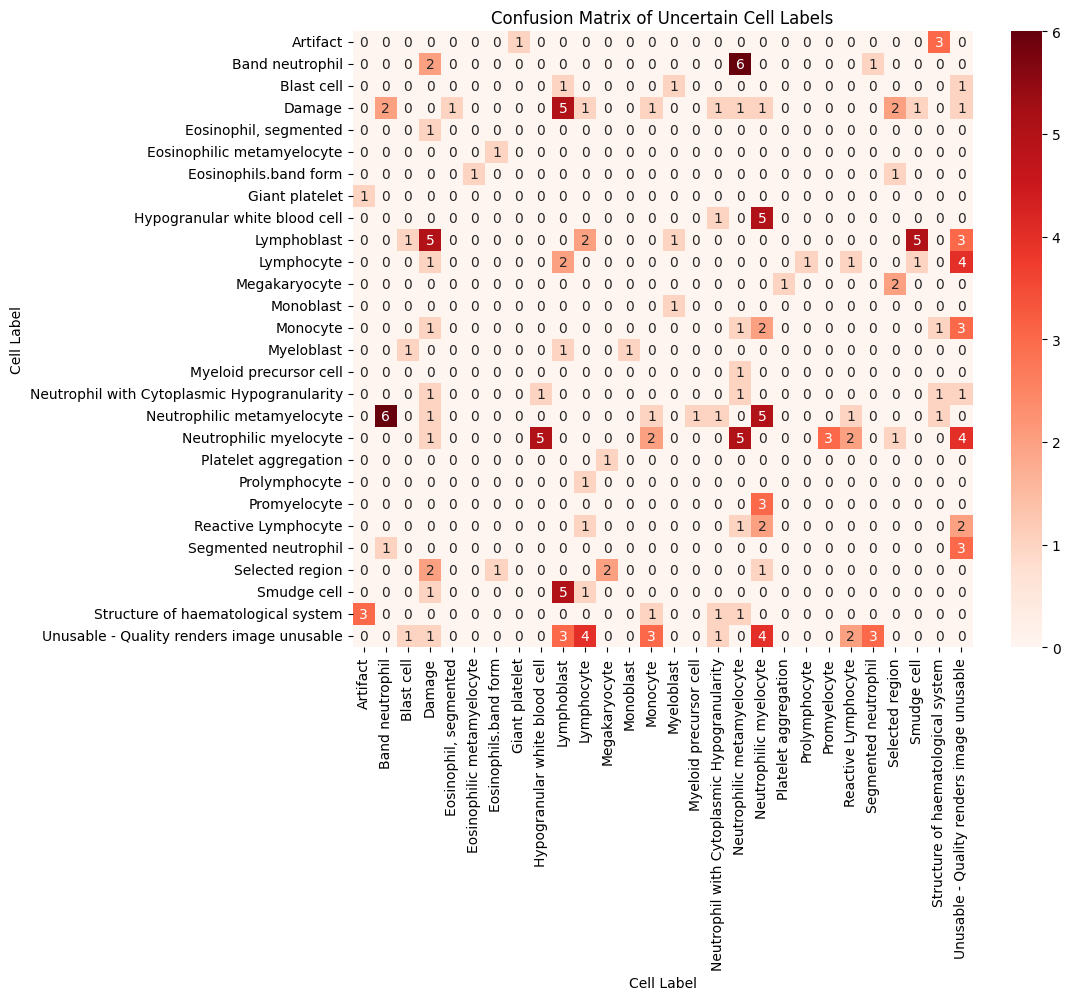

In [15]:
# Flatten all label pairs for each uncertain cell
label_pairs = []
for labels in uncertain_cells['cell_label']:
    unique_labels = list(set(labels))
    if len(unique_labels) > 1:
        # Add all pairwise confusions (unordered, so sort)
        for i in range(len(unique_labels)):
            for j in range(i+1, len(unique_labels)):
                label_pairs.append(tuple(sorted([unique_labels[i], unique_labels[j]])))

# Get all unique labels involved in confusion
all_confused_labels = sorted(set([l for pair in label_pairs for l in pair]))
label_to_idx = {label: idx for idx, label in enumerate(all_confused_labels)}

# Build confusion matrix
conf_matrix = np.zeros((len(all_confused_labels), len(all_confused_labels)), dtype=int)
for l1, l2 in label_pairs:
    i, j = label_to_idx[l1], label_to_idx[l2]
    conf_matrix[i, j] += 1
    conf_matrix[j, i] += 1  # symmetric

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=all_confused_labels, yticklabels=all_confused_labels)
plt.title('Confusion Matrix of Uncertain Cell Labels')
plt.xlabel('Cell Label')
plt.ylabel('Cell Label')
plt.show()

# Next steps

Share your feedback or ask questions about this notebook in IDC Forum: https://discourse.canceridc.dev.

If you are interested in tissue type annotations or want to learn about DICOM Structured Reporting, you can take a look at [this notebook](https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/collections_demos/rms_mutation_prediction/RMS-Mutation-Prediction-Expert-Annotations_exploration.ipynb) navigating expert-generated region annotations for rhabdomyosarcoma tumor slides.

## Support

If you have any questions about this notebook, please post your question on the [IDC User Forum](https://discourse.canceridc.dev) or [open an issue](https://github.com/ImagingDataCommons/IDC-Tutorials/issues/new) in the [IDC Tutorials repository](https://github.com/ImagingDataCommons/IDC-Tutorials).

## Acknowledgments

Imaging Data Commons has been funded in whole or in part with Federal funds from the National Cancer Institute, National Institutes of Health, under Task Order No. HHSN26110071 under Contract No. HHSN261201500003I.

If you use IDC in your research, please cite the following publication:

> Fedorov, A., Longabaugh, W. J. R., Pot, D., Clunie, D. A., Pieper, S. D., Gibbs, D. L., Bridge, C., Herrmann, M. D., Homeyer, A., Lewis, R., Aerts, H. J. W., Krishnaswamy, D., Thiriveedhi, V. K., Ciausu, C., Schacherer, D. P., Bontempi, D., Pihl, T., Wagner, U., Farahani, K., Kim, E. & Kikinis, R. _National Cancer Institute Imaging Data Commons: Toward Transparency, Reproducibility, and Scalability in Imaging Artificial Intelligence_. RadioGraphics (2023). [https://doi.org/10.1148/rg.230180](https://doi.org/10.1148/rg.230180)